In [7]:
print("Milestone 3 EDA Ready")

Milestone 3 EDA Ready


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import os
os.getcwd()

'c:\\Users\\admin\\OneDrive\\Desktop\\AI PRICE OPTIMA\\notebooks'

In [11]:
os.listdir("../data")

['daily_ingest', 'processed', 'raw']

In [12]:
os.listdir("../data/processed")

['sales_cleaned.csv']

In [13]:
df = pd.read_csv("../data/processed/sales_cleaned.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,01-01-2022,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,01-01-2022,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,01-01-2022,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,01-01-2022,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,01-01-2022,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 8.4 MB


In [15]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [16]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [23]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values('Date')

In [28]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='str')

In [35]:
df['Revenue'] = df['Price'] * df['Units Sold']

In [36]:
daily_sales = df.groupby('Date')['Units Sold'].sum()

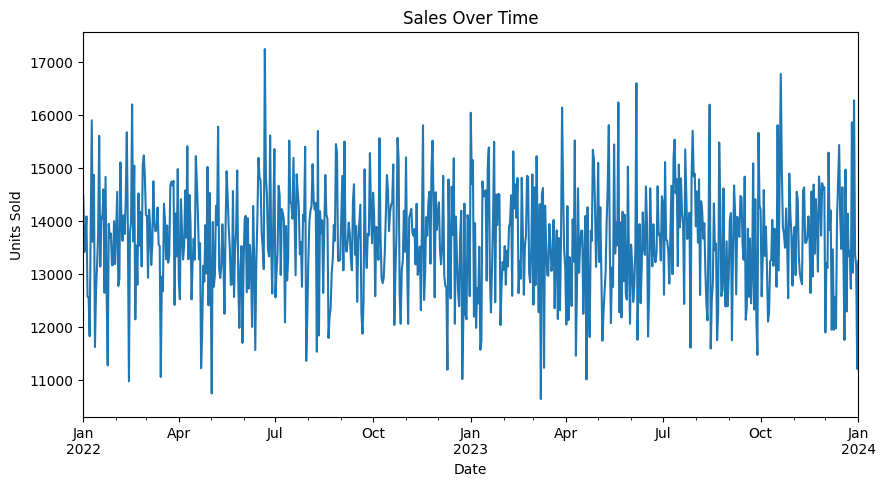

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
daily_sales.plot()
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

In [40]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Revenue'],
      dtype='str')

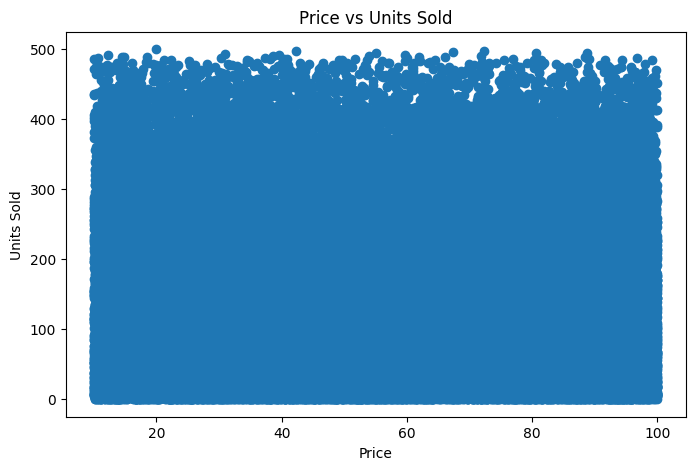

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Price'], df['Units Sold'])
plt.title("Price vs Units Sold")
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.show()

In [42]:
df[['Price','Units Sold']].corr()

,Price,Units Sold
Price,1.000000,0.001082
Units Sold,0.001082,1.000000


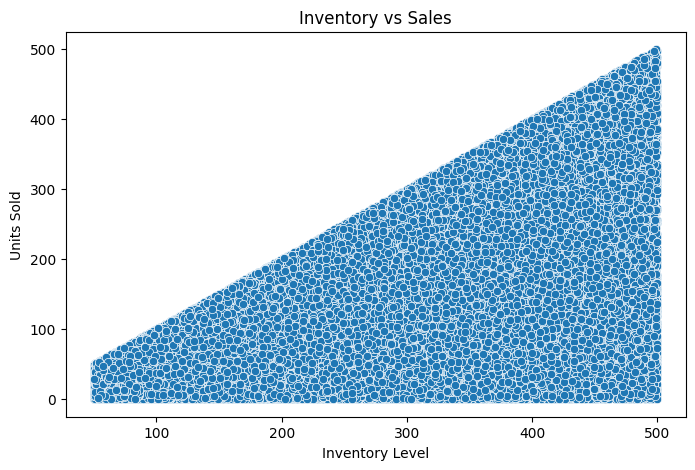

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Inventory Level', y='Units Sold')
plt.title("Inventory vs Sales")
plt.show()

In [53]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Revenue'],
      dtype='str')

In [55]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [56]:
df[['inventory_level','units_sold']].corr()

,inventory_level,units_sold
inventory_level,1.000000,0.589995
units_sold,0.589995,1.000000


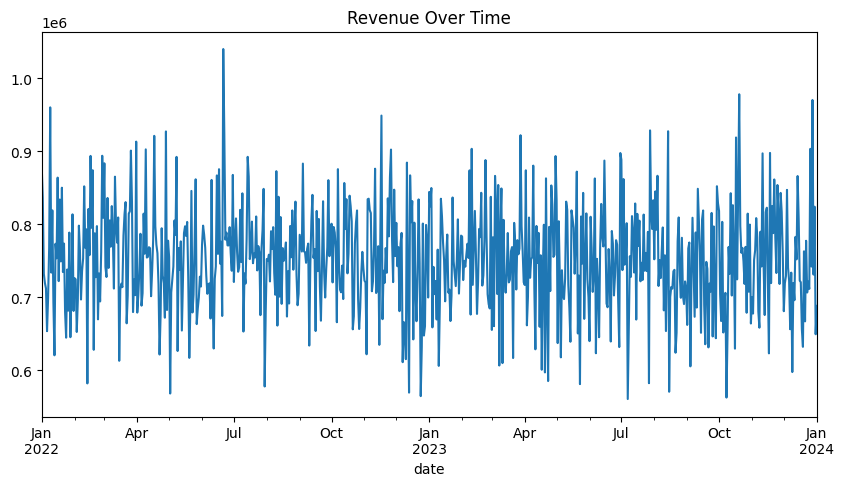

In [58]:
daily_revenue = df.groupby('date')['revenue'].sum()

plt.figure(figsize=(10,5))
daily_revenue.plot()
plt.title("Revenue Over Time")
plt.show()

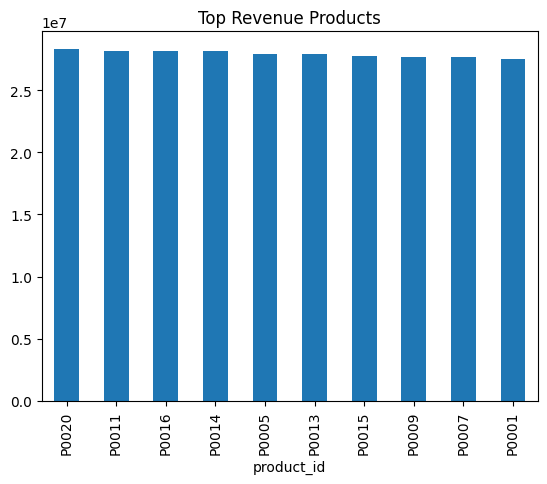

In [59]:
product_revenue = df.groupby('product_id')['revenue'].sum().sort_values(ascending=False)

product_revenue.head(10).plot(kind='bar')
plt.title("Top Revenue Products")
plt.show()

In [63]:
df.columns
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [66]:
df.columns

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast',
       'price', 'discount', 'weather_condition', 'holiday/promotion',
       'competitor_pricing', 'seasonality', 'revenue'],
      dtype='str')

In [68]:
product_sales = df.groupby('product_id')['units_sold'].sum()

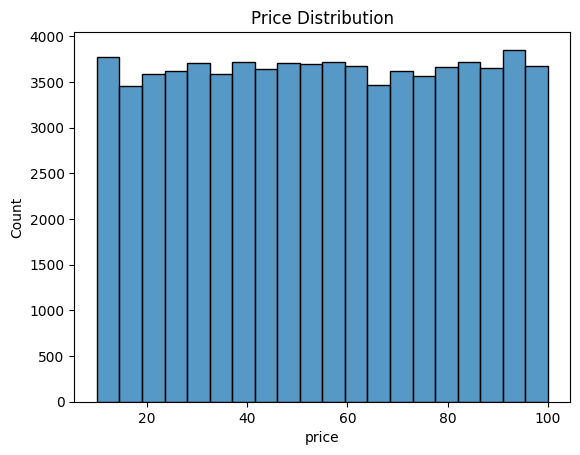

In [69]:
sns.histplot(df['price'], bins=20)
plt.title("Price Distribution")
plt.show()